# PySpark Configuration
## PySpark and Java installation (Linux)
### VSCode (locally)
If you are using VSCode and Linux to run this Jupyter Notebook, PySpark and Java must be installed. PySpark should be installed when you ran the following commands:
```
python -m venv env && source env/bin/activate && pip install -r requirements.txt
```

After installing "pyspark", java must be also installed. In a terminal, run the following commands:
```
sudo apt update && sudo apt install default-jdk
readlink -f $(which javac) | sed "s:/bin/javac::"
```
Copy the output, for example, "/usr/lib/jvm/java-11-openjdk-amd64". Now add the following lines into the ".bashrc" file, replace the path:
```
export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
export PATH=$JAVA_HOME/bin:$PATH
```
Finally, in the terminal run:
```
source ~/.bashrc
```

Create a Spark session:

In [1]:
# SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("TestPySpark").getOrCreate()

26/01/02 13:21:49 WARN Utils: Your hostname, ant resolves to a loopback address: 127.0.1.1; using 192.168.0.7 instead (on interface wlp1s0)
26/01/02 13:21:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/02 13:21:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


If errors did not appeared, PySpark and Java are installed.
Now, read the dataset:

In [2]:
# Local path (VSCode)
path_local = "./data/games.csv"

# Create DataFrame from CSV file
df = spark.read.csv(path_local, header=True, inferSchema=True, sep=',')

# Show the first few rows of the DataFrame
df.show(3)

+-----------------+--------+---------------+--------+-----+
|             name|platform|year_of_release|   genre|sales|
+-----------------+--------+---------------+--------+-----+
|       Wii Sports|     Wii|           2006|  Sports|41.36|
|Super Mario Bros.|     NES|           1985|Platform|29.08|
|   Mario Kart Wii|     Wii|           2008|  Racing|15.68|
+-----------------+--------+---------------+--------+-----+
only showing top 3 rows



### Google Colab
If you are using Google Colab, install PySpark:

In [8]:
# %pip install pyspark

Upload the dataset into "Google Drive" and mount the storage unit with the following line:

In [9]:
# Mount Google Drive if using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

Or you can attach the file manually:

In [10]:
# from google.colab import files
# upload = files.upload()

Using any way, the dataset is now uploaded. Then, read the dataset:

In [ ]:
# Local path (Google Drive)
# path_colab = "/content/drive/MyDrive/games.csv"

# Create DataFrame from CSV file
# df = spark.read.csv(path_colab, header=True, inferSchema=True, sep=',')

# Show the first few rows of the DataFrame
# df.show(3)

## Databricks
If you are using Databricks, no configuration is required, just upload the dataset to the following path for Free Edition (see fig.):
```
/Volumes/workspace/default/test/
```
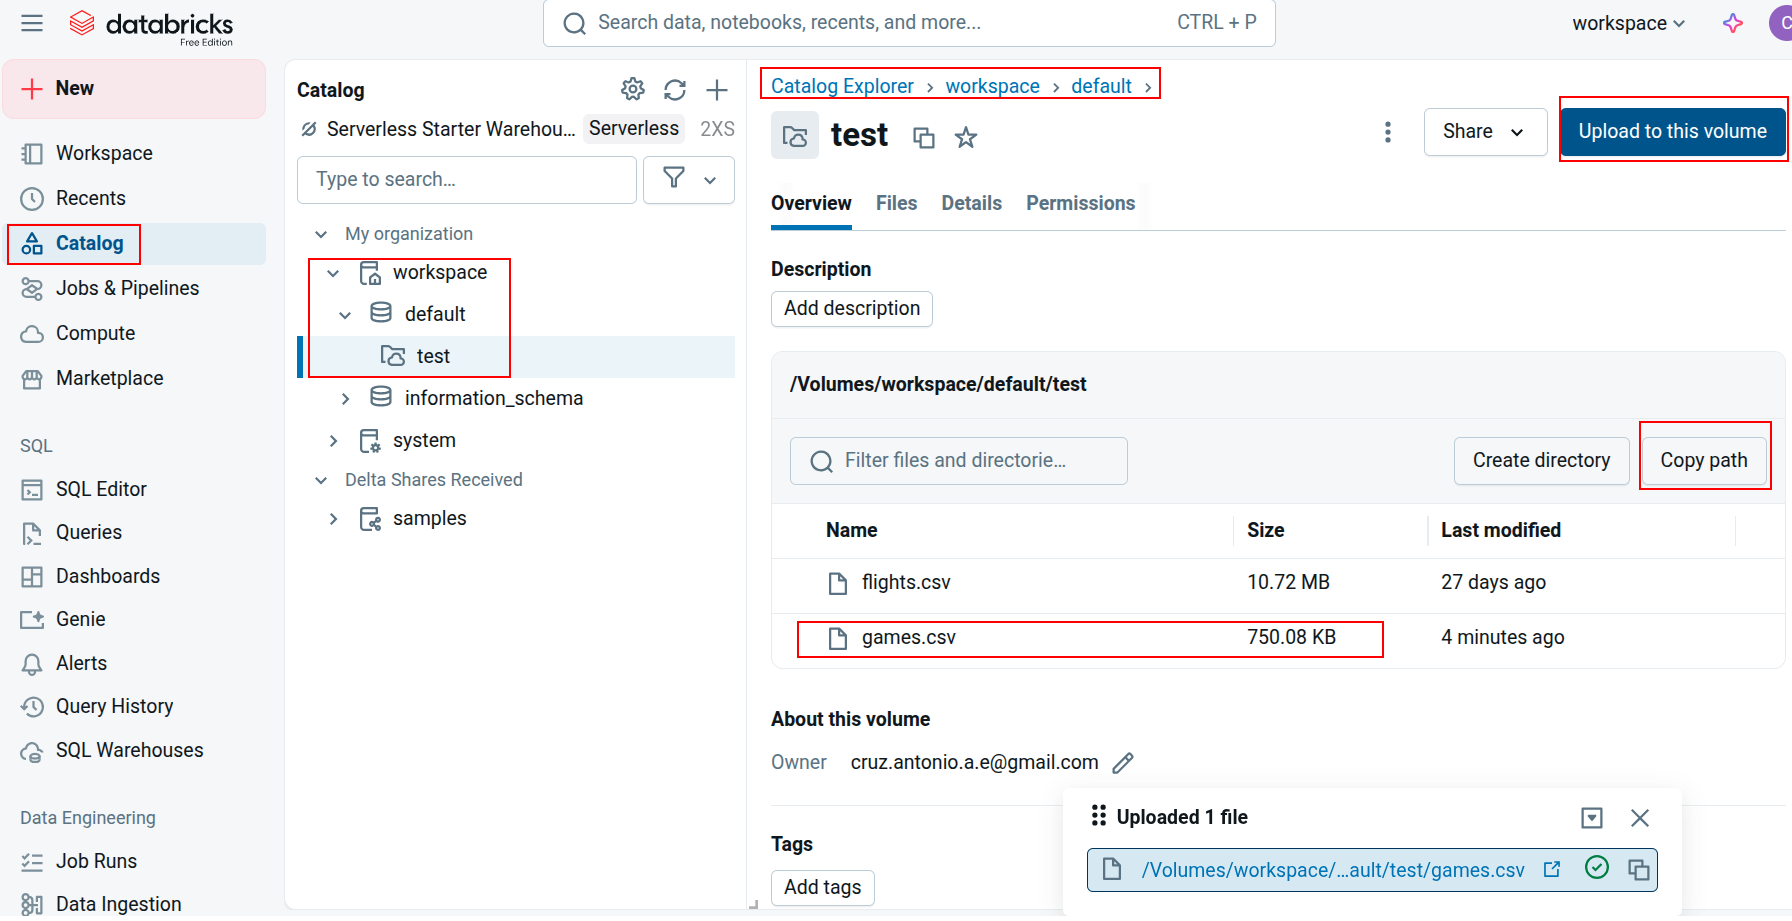

Create a Jupyter Notebook and add the following lines:

In [57]:
# Path in Databricks Free Edition
# path_databricks = "dbfs:/Volumes/workspace/default/test/games.csv"

# Create DataFrame from CSV file
# df = spark.read.csv(path_databricks, header=True, inferSchema=True, sep=',')

# Show the first few rows of the DataFrame
# df.show(3)

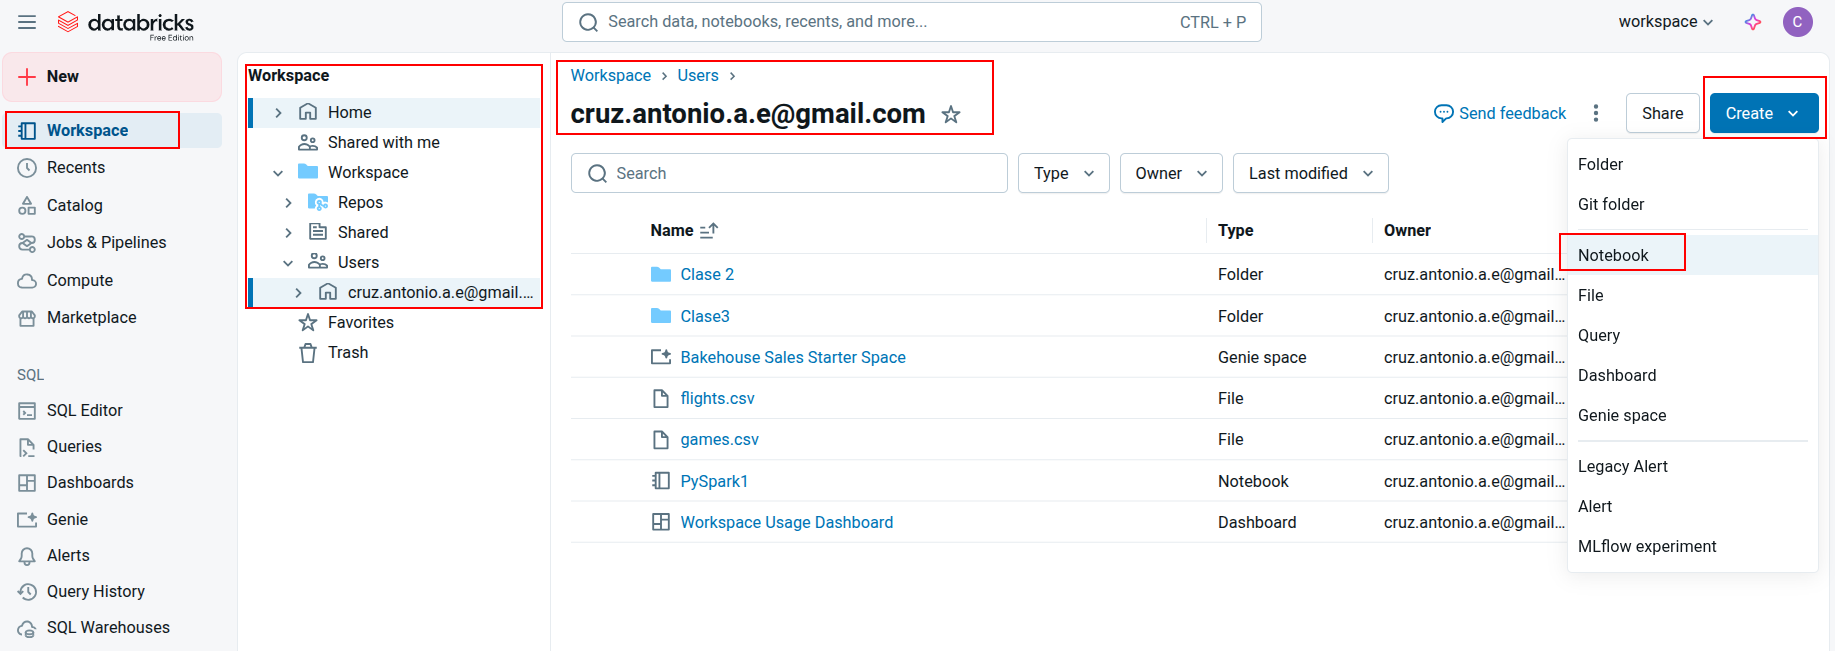

## Complete Spark Session

In [3]:
# SparkSession
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Local")
    .master("local[*]") # For local mode with all available cores
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.cores", "1")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("--- Successful PySpark Configuration ---")
print(f"Execution Mode: {spark.conf.get('spark.master')}")
print(f"Driver Memory: {spark.conf.get('spark.driver.memory')}")
print(f"Executor Memory: {spark.conf.get('spark.executor.memory')}")

--- Successful PySpark Configuration ---
Execution Mode: local[*]
Driver Memory: 2g
Executor Memory: 2g


## DEA Commands
All Dataframes using Pandas, Polars and PySpark will be named by "df", "dp" and "data", respectively.

In [4]:
# Import Pandas libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Import PySpark libraries
import pyspark
from pyspark.sql import SparkSession, SQLContext
from pyspark.sql.types import IntegerType



In [ ]:
# Create Spark session
spark = SparkSession.builder.appName("TestPySpark").getOrCreate()

# Spark session information
spark

In [62]:
# Local path (VSCode)
path_local = "./data/games.csv"

### DataFrames

In [ ]:
# Create a simple DataFrame
df = pd.DataFrame({"Nombre":["Cruz","Antonio"], "ID":[1,2]})

# Show the first rows of the DataFrame
print(df.head())

data = spark.createDataFrame([("Cruz", 1), ("Antonio", 2)], ["Nombre", "ID"])
data.show()

    Nombre  ID
0     Cruz   1
1  Antonio   2
+-------+---+
| Nombre| ID|
+-------+---+
|   Cruz|  1|
|Antonio|  2|
+-------+---+



In [68]:
# Create DataFrame from CSV file
df = pd.read_csv('./data/games.csv',sep=',',header=0)

data = spark.read.csv('./data/games.csv', header=True, inferSchema=True, sep=',')
data.show(3)

+-----------------+--------+---------------+--------+-----+
|             name|platform|year_of_release|   genre|sales|
+-----------------+--------+---------------+--------+-----+
|       Wii Sports|     Wii|           2006|  Sports|41.36|
|Super Mario Bros.|     NES|           1985|Platform|29.08|
|   Mario Kart Wii|     Wii|           2008|  Racing|15.68|
+-----------------+--------+---------------+--------+-----+
only showing top 3 rows



In [66]:
# Show DataFrame Info
df.info()

# Show DataFrame schema
data.printSchema()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   sales            16715 non-null  float64
dtypes: float64(2), object(3)
memory usage: 653.1+ KB
root
 |-- name: string (nullable = true)
 |-- platform: string (nullable = true)
 |-- year_of_release: integer (nullable = true)
 |-- genre: string (nullable = true)
 |-- sales: double (nullable = true)



In [25]:

data.head(3)

[Row(name='Wii Sports', platform='Wii', year_of_release=2006, genre='Sports', sales=41.36),
 Row(name='Super Mario Bros.', platform='NES', year_of_release=1985, genre='Platform', sales=29.08),
 Row(name='Mario Kart Wii', platform='Wii', year_of_release=2008, genre='Racing', sales=15.68)]

In [39]:
# Show the data types of each column
data.dtypes

[('name', 'string'),
 ('platform', 'string'),
 ('year_of_release', 'int'),
 ('genre', 'string'),
 ('sales', 'double')]

In [32]:
# Extract specific columns
data_cols = data[['name','platform']]
data_cols = data.select(['name','platform'])

# Type of the DataFrame columns
type(data_cols)

pyspark.sql.dataframe.DataFrame

In [44]:
data.head(3)

[Row(name='Wii Sports', platform='Wii', year_of_release=2006, genre='Sports', sales=41.36),
 Row(name='Super Mario Bros.', platform='NES', year_of_release=1985, genre='Platform', sales=29.08),
 Row(name='Mario Kart Wii', platform='Wii', year_of_release=2008, genre='Racing', sales=15.68)]

In [47]:
# Column operation
data = data.withColumn('sales2', data['sales']*2)
data.head(3)

[Row(name='Wii Sports', platform='Wii', year_of_release=2006, genre='Sports', sales=41.36, sales2=82.72),
 Row(name='Super Mario Bros.', platform='NES', year_of_release=1985, genre='Platform', sales=29.08, sales2=58.16),
 Row(name='Mario Kart Wii', platform='Wii', year_of_release=2008, genre='Racing', sales=15.68, sales2=31.36)]

In [48]:
# Drop column
data = data.drop('sales2')

In [49]:
# Rename column
data = data.withColumnRenamed('name', 'new_name')

In [ ]:
# Drop rows with null values
data = data.na.drop()

# Drop rows with null values in specific columns
data = data.na.drop(subset=['new_name', 'platform'])

In [52]:
# Fill null values with a specific value
data = data.na.fill({'sales': 0, 'platform': 'other'})

In [53]:
# Fill null values with the mean of the column
from pyspark.sql import functions as F
mean_sales = data.agg(F.avg('sales')).collect()[0][0]
print(mean_sales)

0.2640124057407166


### Filtering

In [54]:
data.head(3)

[Row(new_name='Wii Sports', platform='Wii', year_of_release=2006, genre='Sports', sales=41.36),
 Row(new_name='Super Mario Bros.', platform='NES', year_of_release=1985, genre='Platform', sales=29.08),
 Row(new_name='Mario Kart Wii', platform='Wii', year_of_release=2008, genre='Racing', sales=15.68)]